# Model Combo Benchmark (Demucs x WhisperX)

이 노트북은 `yt-code-lyrics`의 핵심 2개 모델(보컬 분리 + 음성 인식/정렬) 조합을 비교합니다.

- Demucs 모델 크기별 성능/속도
- Whisper 계열 모델 크기별 성능/속도
- 최종 조합 추천(정확도, 속도, 모델 크기 균형)


## 1) 설치/준비

처음 1회는 아래 설치 셀을 실행하세요. (환경에 따라 시간이 걸릴 수 있습니다.)

In [1]:
%pip install -U whisperx demucs jiwer yt-dlp pandas numpy matplotlib seaborn
# ffmpeg 설치는 시스템 레벨에서 필요할 수 있습니다.

  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 2.5 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 2.7 MB/s  0:00:01 eta 0:00:01
Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl (10.8 MB)
Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl (5.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 1.8 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 2.2 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 1.7 MB/s  0:00:07m0:00:0100:01
  Attempting uninstall: yt-dlp
    Found existing installation: yt-dlp 2025.12.8
    Uninstalling yt-dlp-2025.12.8:
      Successfully uninstalled yt-dlp-2025.12.8
  Attempting uninstall:

In [2]:
from __future__ import annotations

import json
import math
import os
import re
import shlex
import subprocess
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from jiwer import wer

import torch
import whisperx
import demucs.separate


## 2) 실험 설정

- `AUDIO_FILES`: 비교할 오디오 샘플 목록 (wav/mp3 등)
- `REFERENCE_LYRICS`: 파일별 정답 가사(문자열)
- `DEMUCS_MODELS`, `ASR_MODELS`: 실험할 모델 크기 목록

정답 가사가 있으면 WER 기반 정확도를 계산하고, 없으면 상대 지표(coverage)만 계산합니다.

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "downloads"
OUT_DIR = PROJECT_ROOT / "benchmark_outputs"
OUT_DIR.mkdir(exist_ok=True)

# 예시: 실제 파일 경로로 바꿔주세요.
AUDIO_FILES = [
    DATA_DIR / "VoEsEC2CLgE.wav",
    DATA_DIR / "CgjknaWVChY.wav",
]

# 파일명(stem) -> 정답 가사(plain text)
REFERENCE_LYRICS = {
    "sample1": """
I see the crystal raindrops fall
And the beauty of it all
Is when the sun comes shining through
To make those rainbows in my mind
When I think of you sometime
And I wanna spend some time with you
Just the two of us
We can make it if we try
Just the two of us
(Just the two of us)
Just the two of us
Building castles in the sky
Just the two of us
You and I
We look for love, no time for tears
Wasted water's all that is
And it don't make no flowers grow
Good things might come to those who wait
Not for those who wait too late
We gotta go for all we know
Just the two of us
We can make it if we try
Just the two of us
(Just the two of us)
Just the two of us
Building them castles in the sky
Just the two of us
You and I
I hear the crystal raindrops fall
On the window down the hall
And it becomes the morning dew
And darling when the morning comes
And I see the morning sun
I wanna be the one with you
Just the two of us
We can make it if we try
Just the two of us
(Just the two of us)
Just the two of us
Building big castles way on high
Just the two of us
You and I
just the two of us
(We can make it, just the two of us)
Let's get it together baby (yeah)
(Just the two of us)
Just the two of us
(We can make it, just the two of us)
(Just the two of us)
(We can make it, just the two of us)
(Just the two of us)
(We can make it, just the two of us)
(Just the two of us)
(We can make it, just the two of us)
(Just the two of us)
(We can make it, just the two of us)
(Just the two of us)""",

"sample2": """
Moon, a hole of light
Through the big top tent up high
Here before and after me
Shining down on me
Moon, tell me if I could
Send up my heart to you?
So, when I die, which I must do
Could it shine down here with you?
'Cause my love is mine, all mine
I love mine, mine, mine
Nothing in the world belongs to me
But my love, mine, all mine, all mine
My baby here on earth
Showed me what my heart was worth
So, when it comes to be my turn
Could you shine it down here for her?
'Cause my love is mine, all mine
I love mine, mine, mine
Nothing in the world belongs to me
But my love, mine, all mine, all mine
Nothing in the world is mine for free
But my love, mine, all mine, all mine
""",
}

# demucs model family
DEMUCS_MODELS = ["htdemucs", "htdemucs_ft", "mdx_extra"]

# whisperx uses whisper models internally
ASR_MODELS = ["tiny", "base", "small", "medium"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
COMPUTE_TYPE = "float16" if DEVICE == "cuda" else "int8"
print(f"device={DEVICE}, compute_type={COMPUTE_TYPE}")

device=cpu, compute_type=int8


In [4]:
def normalize_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9'\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def extract_transcript_from_segments(segments: list[dict]) -> str:
    words = []
    for seg in segments:
        for w in seg.get("words", []):
            wd = (w.get("word") or "").strip()
            if wd:
                words.append(wd)
    if words:
        return " ".join(words)
    # fallback: segment text
    return " ".join((seg.get("text") or "") for seg in segments).strip()


def file_size_mb(path: Path) -> float:
    if not path.exists():
        return np.nan
    return path.stat().st_size / (1024 ** 2)


def estimate_asr_model_size_mb(model_name: str) -> float:
    # 대략적인 참고값(whisper checkpoint)
    table = {
        "tiny": 75,
        "base": 142,
        "small": 466,
        "medium": 1500,
        "large-v2": 2900,
        "large-v3": 3100,
    }
    return float(table.get(model_name, np.nan))


def estimate_demucs_model_size_mb(model_name: str) -> float:
    # 버전/패키지에 따라 달라질 수 있어 대략값 사용
    table = {
        "mdx_extra": 120,
        "htdemucs": 320,
        "htdemucs_ft": 360,
    }
    return float(table.get(model_name, np.nan))

In [5]:
@dataclass
class RunResult:
    audio_file: str
    demucs_model: str
    asr_model: str
    audio_duration_sec: float
    demucs_time_sec: float
    asr_time_sec: float
    total_time_sec: float
    demucs_rtf: float
    asr_rtf: float
    total_rtf: float
    transcript_len: int
    word_timestamp_count: int
    coverage_ratio: float
    wer_score: Optional[float]
    demucs_model_size_mb: float
    asr_model_size_mb: float
    total_model_size_mb: float


def get_audio_duration_sec(audio_path: Path) -> float:
    # ffprobe 필요
    cmd = [
        "ffprobe", "-v", "error", "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1", str(audio_path)
    ]
    out = subprocess.check_output(cmd, text=True).strip()
    return float(out)


def separate_vocals(audio_path: Path, model_name: str, output_root: Path) -> Path:
    output_root.mkdir(parents=True, exist_ok=True)
    cmd = f'-n {model_name} --two-stems vocals -o "{output_root}" "{audio_path}"'
    demucs.separate.main(shlex.split(cmd))
    vocals = output_root / model_name / audio_path.stem / "vocals.wav"
    if not vocals.exists():
        raise FileNotFoundError(f"vocals not found: {vocals}")
    return vocals


def transcribe_with_whisperx(vocal_path: Path, asr_model_name: str):
    model = whisperx.load_model(asr_model_name, DEVICE, compute_type=COMPUTE_TYPE)
    audio = whisperx.load_audio(str(vocal_path))
    result = model.transcribe(audio)
    align_model, align_meta = whisperx.load_align_model(
        language_code=result["language"], device=DEVICE
    )
    aligned = whisperx.align(result["segments"], align_model, align_meta, audio, DEVICE)
    return aligned


def benchmark_one_combo(audio_path: Path, demucs_model: str, asr_model: str) -> RunResult:
    audio_duration = get_audio_duration_sec(audio_path)

    combo_dir = OUT_DIR / f"{audio_path.stem}__{demucs_model}__{asr_model}"
    combo_dir.mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()
    t_demucs0 = time.perf_counter()
    vocal_path = separate_vocals(audio_path, demucs_model, combo_dir / "demucs")
    t_demucs1 = time.perf_counter()

    t_asr0 = time.perf_counter()
    aligned = transcribe_with_whisperx(vocal_path, asr_model)
    t_asr1 = time.perf_counter()
    t1 = time.perf_counter()

    segments = aligned.get("segments", [])
    transcript = extract_transcript_from_segments(segments)

    # 간단한 품질 대체 지표: word timestamp 존재 비율
    ts_count = sum(len(seg.get("words", [])) for seg in segments)
    token_count = max(len(normalize_text(transcript).split()), 1)
    coverage = ts_count / token_count

    ref = REFERENCE_LYRICS.get(audio_path.stem)
    wer_score = None
    if ref:
        wer_score = wer(normalize_text(ref), normalize_text(transcript))

    demucs_size = estimate_demucs_model_size_mb(demucs_model)
    asr_size = estimate_asr_model_size_mb(asr_model)

    result = RunResult(
        audio_file=audio_path.name,
        demucs_model=demucs_model,
        asr_model=asr_model,
        audio_duration_sec=audio_duration,
        demucs_time_sec=t_demucs1 - t_demucs0,
        asr_time_sec=t_asr1 - t_asr0,
        total_time_sec=t1 - t0,
        demucs_rtf=(t_demucs1 - t_demucs0) / max(audio_duration, 1e-6),
        asr_rtf=(t_asr1 - t_asr0) / max(audio_duration, 1e-6),
        total_rtf=(t1 - t0) / max(audio_duration, 1e-6),
        transcript_len=len(transcript),
        word_timestamp_count=ts_count,
        coverage_ratio=coverage,
        wer_score=wer_score,
        demucs_model_size_mb=demucs_size,
        asr_model_size_mb=asr_size,
        total_model_size_mb=demucs_size + asr_size,
    )

    with open(combo_dir / "aligned.json", "w", encoding="utf-8") as f:
        json.dump(aligned, f, ensure_ascii=False, indent=2)

    with open(combo_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(asdict(result), f, ensure_ascii=False, indent=2)

    # 메모리 정리
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## 3) 벤치마크 실행

샘플이 많으면 시간이 오래 걸리므로 먼저 1~2개 샘플로 시작하는 것을 권장합니다.

In [6]:
if not AUDIO_FILES:
    raise ValueError("AUDIO_FILES가 비어 있습니다. 먼저 오디오 파일 경로를 넣어주세요.")

all_results: list[RunResult] = []

for audio_path in AUDIO_FILES:
    audio_path = Path(audio_path)
    print(f"\n=== audio: {audio_path.name} ===")
    for d_model in DEMUCS_MODELS:
        for a_model in ASR_MODELS:
            print(f"- running demucs={d_model}, asr={a_model}")
            try:
                rr = benchmark_one_combo(audio_path, d_model, a_model)
                all_results.append(rr)
                print(f"  done: total={rr.total_time_sec:.1f}s, rtf={rr.total_rtf:.3f}, wer={rr.wer_score}")
            except Exception as e:
                print(f"  failed: {e}")

df = pd.DataFrame([asdict(r) for r in all_results])
df.to_csv(OUT_DIR / "benchmark_results.csv", index=False)
df.head()


=== audio: VoEsEC2CLgE.wav ===
- running demucs=htdemucs, asr=tiny
Downloading: "https://dl.fbaipublicfiles.com/demucs/hybrid_transformer/955717e8-8726e21a.th" to /Users/kyungmin/.cache/torch/hub/checkpoints/955717e8-8726e21a.th


100%|██████████| 80.2M/80.2M [01:39<00:00, 846kB/s] 


Selected model is a bag of 1 models. You will see that many progress bars per track.
Separated tracks will be stored in /Users/kyungmin/Desktop/Projects/yt-code-lyrics/benchmark_outputs/VoEsEC2CLgE__htdemucs__tiny/demucs/htdemucs
Separating track /Users/kyungmin/Desktop/Projects/yt-code-lyrics/downloads/VoEsEC2CLgE.wav


100%|████████████████████████████████████████████████████████████████████████| 234.0/234.0 [01:11<00:00,  3.26seconds/s]
/Users/kyungmin/Desktop/Projects/yt-code-lyrics/venv/lib/python3.10/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(
/Users/kyungmin/Desktop/Projects/yt-code-lyrics/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/kyungmin/Desktop/Projects/yt-code-lyrics/venv/lib/pyt

2026-04-25 19:56:23 - whisperx.asr - INFO - No language specified, language will be detected for each audio file (increases inference time)
2026-04-25 19:56:23 - whisperx.vads.pyannote - INFO - Performing voice activity detection using Pyannote...


...

100%|████████████████████████████████████████████████████████████████████████| 165.0/165.0 [00:24<00:00,  6.87seconds/s]
100%|████████████████████████████████████████████████████████████████████████| 165.0/165.0 [00:24<00:00,  6.64seconds/s]
100%|████████████████████████████████████████████████████████████████████████| 165.0/165.0 [00:24<00:00,  6.78seconds/s]
100%|████████████████████████████████████████████████████████████████████████| 165.0/165.0 [00:24<00:00,  6.71seconds/s]
/Users/kyungmin/Desktop/Projects/yt-code-lyrics/venv/lib/python3.10/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
 

2026-04-25 21:32:27 - whisperx.asr - INFO - No language specified, language will be detected for each audio file (increases inference time)
2026-04-25 21:32:27 - whisperx.vads.pyannote - INFO - Performing voice activity detection using Pyannote...


Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.0. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../venv/lib/python3.10/site-packages/whisperx/assets/pytorch_model.bin`


2026-04-25 21:32:38 - whisperx.asr - INFO - Detected language: en (0.85) in first 30s of audio
  done: total=129.9s, rtf=0.939, wer=None


,audio_file,demucs_model,asr_model,audio_duration_sec,demucs_time_sec,asr_time_sec,total_time_sec,demucs_rtf,asr_rtf,total_rtf,transcript_len,word_timestamp_count,coverage_ratio,wer_score,demucs_model_size_mb,asr_model_size_mb,total_model_size_mb
0,VoEsEC2CLgE.wav,htdemucs,tiny,232.814896,172.236507,286.252877,458.489384,0.739800,1.229530,1.969330,1553,377,1.0,None,320.0,75.0,395.0
1,VoEsEC2CLgE.wav,htdemucs,base,232.814896,73.536163,72.810030,146.346193,0.315857,0.312738,0.628595,1251,281,1.0,None,320.0,142.0,462.0
2,VoEsEC2CLgE.wav,htdemucs,small,232.814896,73.157749,253.612231,326.769980,0.314231,1.089330,1.403561,1233,284,1.0,None,320.0,466.0,786.0
3,VoEsEC2CLgE.wav,htdemucs,medium,232.814896,74.688538,587.798840,662.487378,0.320807,2.524748,2.845554,1241,285,1.0,None,320.0,1500.0,1820.0
4,VoEsEC2CLgE.wav,htdemucs_ft,tiny,232.814896,543.156657,24.268737,567.425395,2.332998,0.104240,2.437238,1159,253,1.0,None,360.0,75.0,435.0


## 4) 스코어링 및 추천 조합

기본 정책:
- 정확도: `WER`가 있으면 `1-WER`, 없으면 `coverage_ratio` 사용
- 속도: `total_rtf` 낮을수록 유리
- 용량: `total_model_size_mb` 낮을수록 유리

가중치(`w_acc`, `w_speed`, `w_size`)를 프로젝트 목표에 맞게 조절하세요.

In [10]:
if df.empty:
    raise ValueError("결과가 없습니다. 벤치마크 셀을 먼저 실행하세요.")

agg = (
    df.groupby(["demucs_model", "asr_model"], as_index=False)
      .agg(
          total_rtf=("total_rtf", "mean"),
          total_model_size_mb=("total_model_size_mb", "mean"),
          coverage_ratio=("coverage_ratio", "mean"),
          wer_score=("wer_score", "mean"),
          n_runs=("audio_file", "count"),
      )
)

agg["accuracy"] = np.where(agg["wer_score"].notna(), 1 - agg["wer_score"], agg["coverage_ratio"])

def minmax(col: pd.Series, reverse: bool = False) -> pd.Series:
    x = col.astype(float)
    mn, mx = x.min(), x.max()
    if math.isclose(mx, mn):
        out = pd.Series(np.ones(len(x)), index=x.index)
    else:
        out = (x - mn) / (mx - mn)
    return 1 - out if reverse else out

# 높을수록 좋게 정규화
agg["acc_norm"] = minmax(agg["accuracy"], reverse=False)
agg["speed_norm"] = minmax(agg["total_rtf"], reverse=True)         # rtf 낮을수록 좋음
agg["size_norm"] = minmax(agg["total_model_size_mb"], reverse=True) # 용량 낮을수록 좋음

w_acc, w_speed, w_size = 0.50, 0.30, 0.20
agg["final_score"] = (
    w_acc * agg["acc_norm"] +
    w_speed * agg["speed_norm"] +
    w_size * agg["size_norm"]
)

ranked = agg.sort_values("final_score", ascending=False).reset_index(drop=True)

# 섹션 4 결과 저장
agg.to_csv(OUT_DIR / "section4_agg.csv", index=False)
ranked.to_csv(OUT_DIR / "section4_ranked.csv", index=False)
print(f"saved: {OUT_DIR / 'section4_agg.csv'}")
print(f"saved: {OUT_DIR / 'section4_ranked.csv'}")

ranked.head(10)

saved: /Users/kyungmin/Desktop/Projects/yt-code-lyrics/benchmark_outputs/section4_agg.csv
saved: /Users/kyungmin/Desktop/Projects/yt-code-lyrics/benchmark_outputs/section4_ranked.csv


,demucs_model,asr_model,total_rtf,total_model_size_mb,coverage_ratio,wer_score,n_runs,accuracy,acc_norm,speed_norm,size_norm,final_score
0,htdemucs,base,0.535676,462.0,1.0,NaN,2,1.0,1.0,1.000000,0.839640,0.967928
1,mdx_extra,base,0.838325,262.0,1.0,NaN,2,1.0,1.0,0.778040,0.959760,0.925364
2,mdx_extra,small,0.859723,586.0,1.0,NaN,2,1.0,1.0,0.762346,0.765165,0.881737
3,htdemucs,small,0.936537,786.0,1.0,NaN,2,1.0,1.0,0.706011,0.645045,0.840812
4,htdemucs,tiny,1.196401,395.0,1.0,NaN,2,1.0,1.0,0.515429,0.879880,0.830605
5,htdemucs_ft,base,1.387686,502.0,1.0,NaN,2,1.0,1.0,0.375141,0.815616,0.775666
6,mdx_extra,medium,0.953161,1620.0,1.0,NaN,2,1.0,1.0,0.693819,0.144144,0.736975
7,htdemucs_ft,small,1.470844,826.0,1.0,NaN,2,1.0,1.0,0.314154,0.621021,0.718450
8,htdemucs_ft,tiny,1.899200,435.0,1.0,NaN,2,1.0,1.0,0.000000,0.855856,0.671171
9,htdemucs_ft,medium,1.522264,1860.0,1.0,NaN,2,1.0,1.0,0.276443,0.000000,0.582933


In [12]:
# Pareto front (정확도 maximize, rtf minimize, size minimize)
rows = ranked.copy()
rows["dominated"] = False

for i in range(len(rows)):
    for j in range(len(rows)):
        if i == j:
            continue
        a = rows.iloc[i]
        b = rows.iloc[j]
        b_better_or_equal = (
            (b["accuracy"] >= a["accuracy"]) and
            (b["total_rtf"] <= a["total_rtf"]) and
            (b["total_model_size_mb"] <= a["total_model_size_mb"])
        )
        b_strictly_better = (
            (b["accuracy"] > a["accuracy"]) or
            (b["total_rtf"] < a["total_rtf"]) or
            (b["total_model_size_mb"] < a["total_model_size_mb"])
        )
        if b_better_or_equal and b_strictly_better:
            rows.loc[i, "dominated"] = True
            break

pareto = rows[~rows["dominated"]].sort_values("final_score", ascending=False)

# 섹션 4 결과 저장 (Pareto)
pareto.to_csv(OUT_DIR / "section4_pareto.csv", index=False)
print(f"saved: {OUT_DIR / 'section4_pareto.csv'}")

pareto[["demucs_model", "asr_model", "accuracy", "total_rtf", "total_model_size_mb", "final_score"]]

saved: /Users/kyungmin/Desktop/Projects/yt-code-lyrics/benchmark_outputs/section4_pareto.csv


,demucs_model,asr_model,accuracy,total_rtf,total_model_size_mb,final_score
0,htdemucs,base,1.0,0.535676,462.0,0.967928
1,mdx_extra,base,1.0,0.838325,262.0,0.925364
11,mdx_extra,tiny,0.966312,1.414613,195.0,0.306618


## 5) 시각화

saved: /Users/kyungmin/Desktop/Projects/yt-code-lyrics/benchmark_outputs/section5_tradeoff_scatter.png


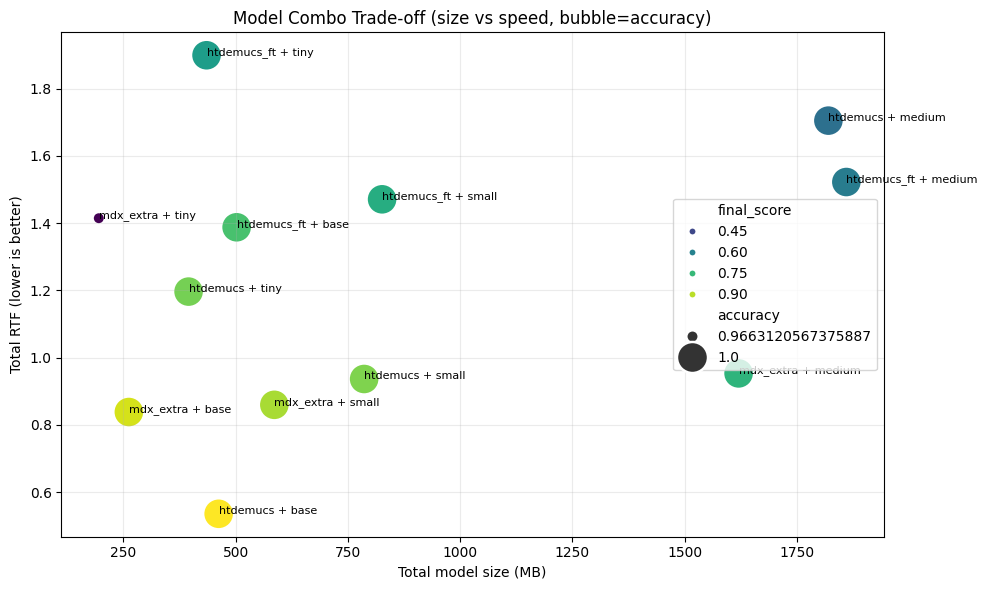

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = ranked.copy()
plot_df["label"] = plot_df["demucs_model"] + " + " + plot_df["asr_model"]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="total_model_size_mb",
    y="total_rtf",
    size="accuracy",
    hue="final_score",
    sizes=(80, 500),
    palette="viridis",
)
for _, r in plot_df.iterrows():
    plt.text(r["total_model_size_mb"], r["total_rtf"], r["label"], fontsize=8)

plt.title("Model Combo Trade-off (size vs speed, bubble=accuracy)")
plt.xlabel("Total model size (MB)")
plt.ylabel("Total RTF (lower is better)")
plt.grid(alpha=0.25)
plt.tight_layout()

# 섹션 5 결과 저장
fig_path = OUT_DIR / "section5_tradeoff_scatter.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"saved: {fig_path}")

plt.show()

## 6) 추천 해석 가이드

- `final_score` 1위: 현재 가중치 기준 최적 조합
- `pareto`: 어떤 지표에서도 일방적으로 밀리지 않는 후보군
- 서비스 운영에서는 보통 `pareto` 중에서 **지연시간 안정성**(p95 latency)까지 보고 최종 선택하는 것이 안전합니다.

In [14]:
# 섹션 6 결과 저장 (추천 리포트)
if "ranked" not in globals() or ranked.empty:
    raise ValueError("ranked가 비어 있습니다. 섹션 4 셀을 먼저 실행하세요.")

if "pareto" not in globals() or pareto.empty:
    raise ValueError("pareto가 비어 있습니다. 섹션 4의 Pareto 셀을 먼저 실행하세요.")

top1 = ranked.iloc[0]
report = {
    "best_combo": {
        "demucs_model": top1["demucs_model"],
        "asr_model": top1["asr_model"],
        "accuracy": float(top1["accuracy"]),
        "total_rtf": float(top1["total_rtf"]),
        "total_model_size_mb": float(top1["total_model_size_mb"]),
        "final_score": float(top1["final_score"]),
    },
    "weights": {
        "w_acc": float(w_acc),
        "w_speed": float(w_speed),
        "w_size": float(w_size),
    },
    "pareto_candidates": pareto[["demucs_model", "asr_model", "accuracy", "total_rtf", "total_model_size_mb", "final_score"]].to_dict(orient="records"),
}

json_path = OUT_DIR / "section6_recommendation.json"
md_path = OUT_DIR / "section6_recommendation.md"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

lines = []
lines.append("# Section 6 Recommendation")
lines.append("")
lines.append("## Best Combo")
lines.append(f"- demucs: `{report['best_combo']['demucs_model']}`")
lines.append(f"- asr: `{report['best_combo']['asr_model']}`")
lines.append(f"- accuracy: {report['best_combo']['accuracy']:.4f}")
lines.append(f"- total_rtf: {report['best_combo']['total_rtf']:.4f}")
lines.append(f"- total_model_size_mb: {report['best_combo']['total_model_size_mb']:.1f}")
lines.append(f"- final_score: {report['best_combo']['final_score']:.4f}")
lines.append("")
lines.append("## Weights")
lines.append(f"- w_acc: {report['weights']['w_acc']}")
lines.append(f"- w_speed: {report['weights']['w_speed']}")
lines.append(f"- w_size: {report['weights']['w_size']}")
lines.append("")
lines.append("## Pareto Candidate Count")
lines.append(f"- {len(report['pareto_candidates'])}")

with open(md_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print(f"saved: {json_path}")
print(f"saved: {md_path}")
report

saved: /Users/kyungmin/Desktop/Projects/yt-code-lyrics/benchmark_outputs/section6_recommendation.json
saved: /Users/kyungmin/Desktop/Projects/yt-code-lyrics/benchmark_outputs/section6_recommendation.md


{'best_combo': {'demucs_model': 'htdemucs',
  'asr_model': 'base',
  'accuracy': 1.0,
  'total_rtf': 0.5356764089514304,
  'total_model_size_mb': 462.0,
  'final_score': 0.967927927927928},
 'weights': {'w_acc': 0.5, 'w_speed': 0.3, 'w_size': 0.2},
 'pareto_candidates': [{'demucs_model': 'htdemucs',
   'asr_model': 'base',
   'accuracy': 1.0,
   'total_rtf': 0.5356764089514304,
   'total_model_size_mb': 462.0,
   'final_score': 0.967927927927928},
  {'demucs_model': 'mdx_extra',
   'asr_model': 'base',
   'accuracy': 1.0,
   'total_rtf': 0.8383246626292342,
   'total_model_size_mb': 262.0,
   'final_score': 0.9253638386617975},
  {'demucs_model': 'mdx_extra',
   'asr_model': 'tiny',
   'accuracy': 0.9663120567375887,
   'total_rtf': 1.4146133044699507,
   'total_model_size_mb': 195.0,
   'final_score': 0.30661791745875805}]}